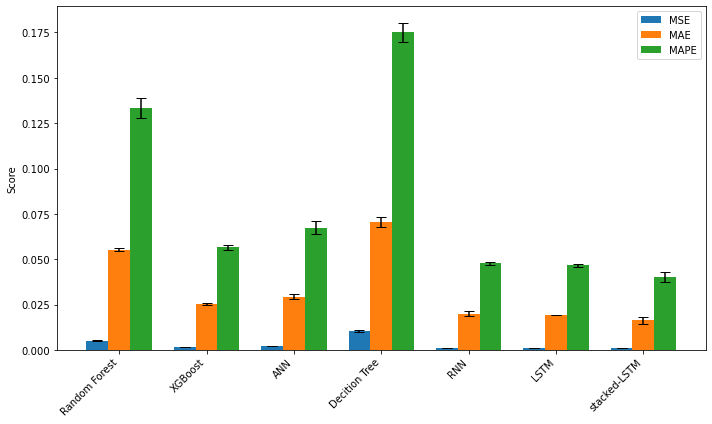

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load your Excel (adjust path if needed)
file_path = 'results.xlsx'
df = pd.read_excel(file_path, sheet_name='general', header=[0,1])

# 2. Extract model names
#    (the “model” column lives under level-0 name 'Unnamed: 0_level_0')
models = df[('Unnamed: 0_level_0', 'model')].astype(str).tolist()

# 3. Select the three metrics you want
metrics = ['MSE', 'MAE', 'MAPE']

# 4. Grab means and stds
means = df['mean'][metrics].values    # shape (n_models, 3)
stds  = df['std'][ metrics].values

# 5. Plot
x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
for i, metric in enumerate(metrics):
    ax.bar(x + i*width, 
           means[:, i], 
           width, 
           yerr=stds[:, i], 
           capsize=5, 
           label=metric)

# 6. Formatting
ax.set_xticks(x + width)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_ylabel('Score')
# ax.set_title('Model Comparison: Mean ± Std (MSE, MAE, MAPE)')
ax.legend()
# ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('error bar plot.png', dpi=600)


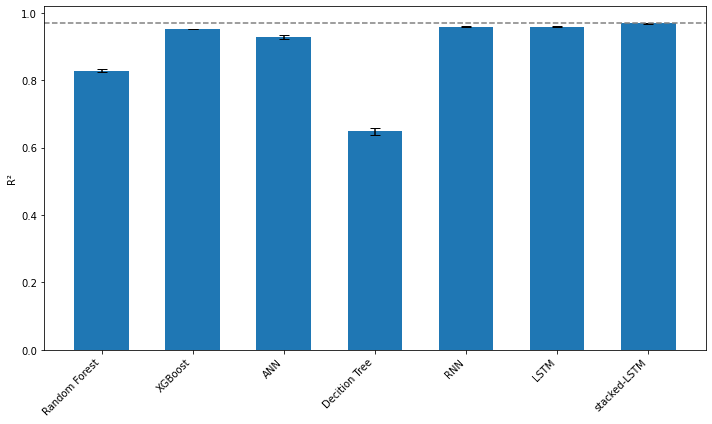

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the Excel sheet
file_path = 'results.xlsx'
df = pd.read_excel(file_path, sheet_name='general', header=[0,1])

# 2. Extract model names
models = df[('Unnamed: 0_level_0', 'model')].astype(str).tolist()

# 3. Grab R2 mean and std
mean_r2 = df['mean']['R2'].values    # shape (n_models,)
std_r2  = df['std']['R2'].values

# 4. Plot
x = np.arange(len(models))
width = 0.6

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x, mean_r2, width, yerr=std_r2, capsize=5, label='R²')
target = 0.968466667
ax.axhline(target, linestyle='--', linewidth=1.5, color='gray', label=f'Target R² = {target}')

# 5. Formatting
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_ylabel('R²')
# ax.set_title('Model Comparison: R² (Mean ± Std)')
# ax.grid(axis='y', linestyle='--', alpha=0.6)
# plt.yscale('log')
plt.tight_layout()
plt.show()


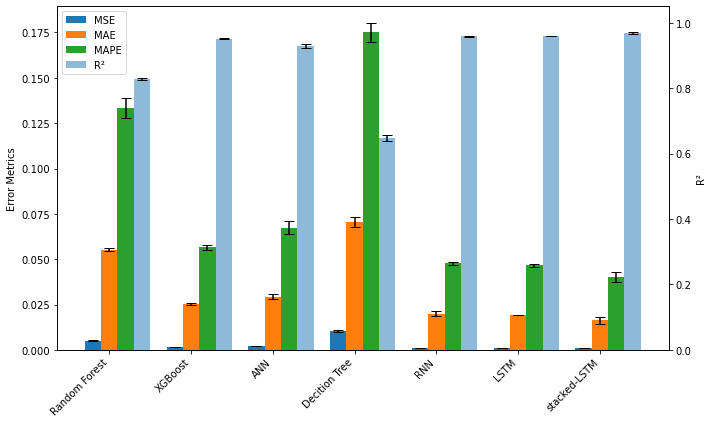

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the Excel sheet
file_path = 'results.xlsx'
df = pd.read_excel(file_path, sheet_name='general', header=[0,1])

# 2. Extract model names
models = df[('Unnamed: 0_level_0', 'model')].astype(str).tolist()

# 3. Prepare data
metrics_left = ['MSE', 'MAE', 'MAPE']
means_left = df['mean'][metrics_left].values    # shape (n_models, 3)
stds_left  = df['std'][ metrics_left].values

mean_r2 = df['mean']['R2'].values              # shape (n_models,)
std_r2  = df['std']['R2'].values

# 4. Plot
x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

# Left axis: MSE, MAE, MAPE
for i, metric in enumerate(metrics_left):
    ax.bar(
        x + (i-1)*width,                 # positions: -width, 0, +width
        means_left[:, i],
        width,
        yerr=stds_left[:, i],
        capsize=5,
        label=metric
    )
ax.set_ylabel('Error Metrics')
ax.set_ylim(bottom=0)  # ensure starts at zero

# Right axis: R²
ax2 = ax.twinx()
ax2.bar(
    x + 2*width,          # offset to the right
    mean_r2,
    width,
    yerr=std_r2,
    capsize=5,
    label='R²',
    alpha=0.5
)
ax2.set_ylabel('R²')
ax2.set_ylim(0, 1.05)   # R² is between 0 and 1

# 5. Add horizontal dashed target line on right axis
# target = 0.968466667
# ax2.axhline(target, linestyle='--', linewidth=1.5, color='gray')

# 6. Formatting
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
# ax.set_title('Model Comparison\nError Metrics (MSE, MAE, MAPE) & R²')

# Combined legend
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper left')

# ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('bar plots.png', dpi=600)


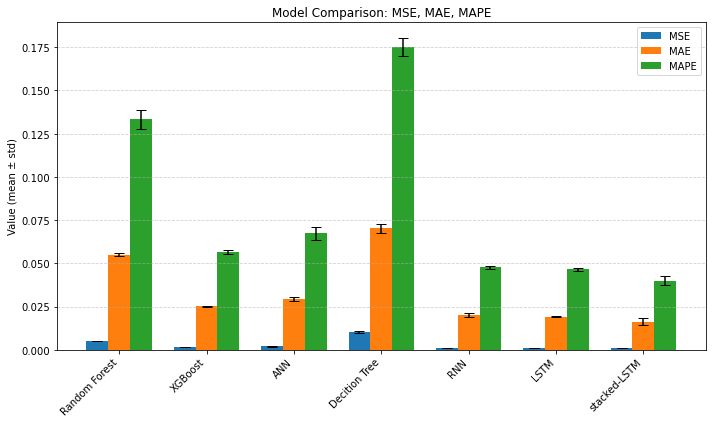

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the entire sheet with two header rows
file_path = 'results.xlsx'
df = pd.read_excel(file_path, sheet_name='general', header=[0, 1])

# 2. Extract model names (first column under multi-index)
models = df[('Unnamed: 0_level_0', 'model')].astype(str).tolist()

# 3. Specify which multi-index columns correspond to means and stds
mean_cols = [('mean', 'MSE'), ('mean', 'MAE'), ('mean', 'MAPE')]
std_cols  = [('std',  'MSE'), ('std',  'MAE'), ('std',  'MAPE')]

# 4. Build arrays for plotting
means = np.column_stack([df[col].values for col in mean_cols])
stds  = np.column_stack([df[col].values for col in std_cols])

# 5. Plot
x       = np.arange(len(models))
width   = 0.25
metrics = ['MSE', 'MAE', 'MAPE']

fig, ax = plt.subplots(figsize=(10, 6))
for i, metric in enumerate(metrics):
    ax.bar(
        x + (i - 1) * width,  # positions: -width, 0, +width
        means[:, i],
        width,
        yerr=stds[:, i],
        capsize=5,
        label=metric
    )

# 6. Formatting
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_ylabel('Value (mean ± std)')
ax.set_title('Model Comparison: MSE, MAE, MAPE')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


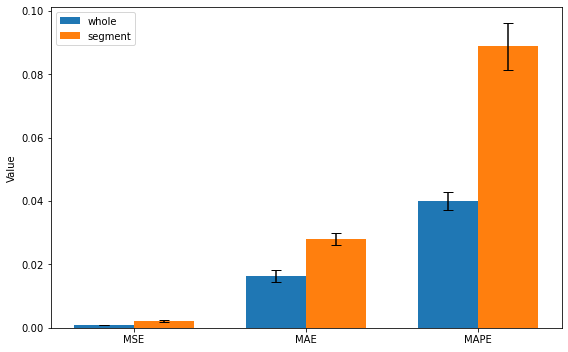

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['whole', 'segment']
metrics = ['MSE', 'MAE', 'MAPE']
means = np.array([
    [0.000933333, 0.016366667, 0.040066667],
    [0.002133333, 0.028166667, 0.088833333]
])
stds = np.array([
    [5.7735e-05, 0.001871719, 0.002759227],
    [0.000208167, 0.001900877, 0.007450056]
])

# Plot
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
for i, model in enumerate(models):
    ax.bar(x + (i - 0.5) * width, means[i], width, yerr=stds[i],
           capsize=5, label=model)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Value')
# ax.set_title('Model Comparison: MSE, MAE, MAPE')
ax.legend()
# ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('use segment.png', dpi=600)


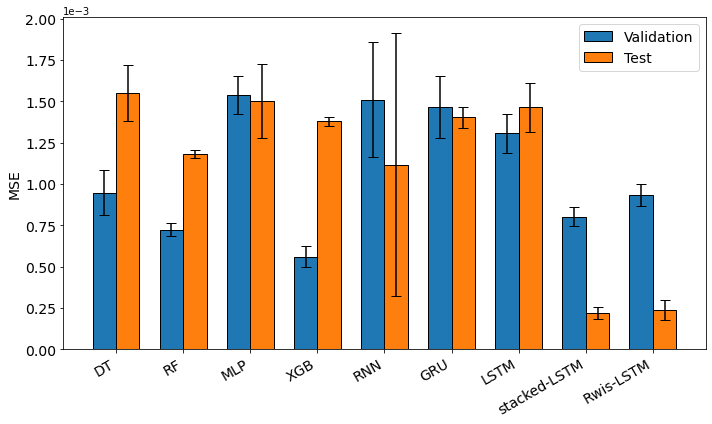

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取 Excel
df = pd.read_excel('results.xlsx', sheet_name='leave_out_158')

# 2. 提取数据
models     = df['model'].tolist()
val_means  = df['val_MSE_avg'].tolist()
test_means = df['test_MSE_avg'].tolist()
val_stds   = df['val_MSE_std'].tolist()
test_stds  = df['test_MSE_std'].tolist()

# 3. 绘图准备
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# 4. 绘制柱状图及误差棒
ax.bar(x - width/2, val_means,  width, yerr=val_stds,  label='Validation', capsize=5,   edgecolor='black',   # 黑色边框
    linewidth=1)
ax.bar(x + width/2, test_means, width, yerr=test_stds, label='Test',       capsize=5,   edgecolor='black',   # 黑色边框
    linewidth=1)

# 5. 美化与标注
ax.set_ylabel('MSE',fontsize=14)
# ax.set_title('Validation vs Test R² by Model (Leave-out 158)')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right',fontsize=14)
# plt.ylim(0.5,1)
ax.legend(fontsize=14)

ax.tick_params(axis='y', labelsize=14)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.savefig('leave out 158.png', dpi=600)


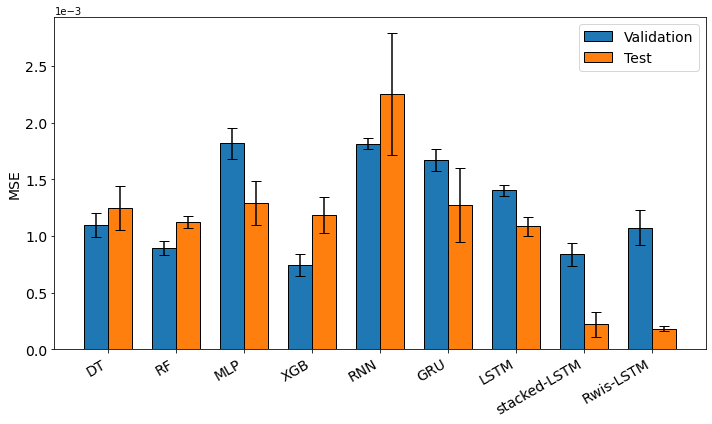

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取 Excel
df = pd.read_excel('results.xlsx', sheet_name='leave_out_26')

# 2. 提取数据
models     = df['model'].tolist()
val_means  = df['val_MSE_avg'].tolist()
test_means = df['test_MSE_avg'].tolist()
val_stds   = df['val_MSE_std'].tolist()
test_stds  = df['test_MSE_std'].tolist()

# 3. 绘图准备
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# 4. 绘制柱状图及误差棒
ax.bar(x - width/2, val_means,  width, yerr=val_stds,  label='Validation', capsize=5,   edgecolor='black',   # 黑色边框
    linewidth=1)
ax.bar(x + width/2, test_means, width, yerr=test_stds, label='Test',       capsize=5,   edgecolor='black',   # 黑色边框
    linewidth=1)

# 5. 美化与标注
ax.set_ylabel('MSE',fontsize=14)
# ax.set_title('Validation vs Test R² by Model (Leave-out 158)')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right',fontsize=14)
# plt.ylim(0.5,1)
ax.legend(fontsize=14)

ax.tick_params(axis='y', labelsize=14)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.savefig('leave out 26.png', dpi=600)


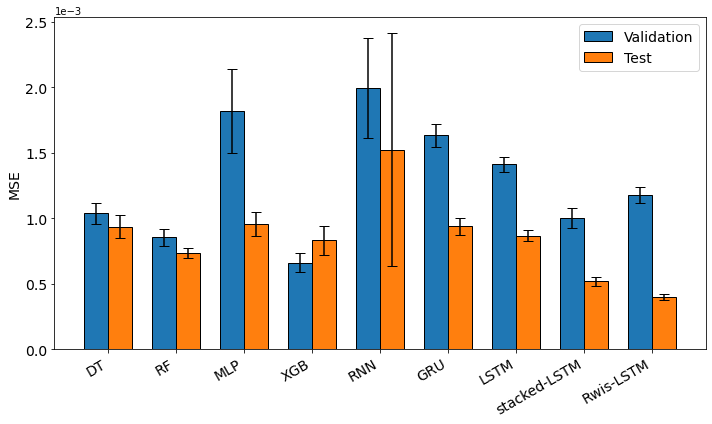

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取 Excel
df = pd.read_excel('results.xlsx', sheet_name='leave_out_27')

# 2. 提取数据
models     = df['model'].tolist()
val_means  = df['val_MSE_avg'].tolist()
test_means = df['test_MSE_avg'].tolist()
val_stds   = df['val_MSE_std'].tolist()
test_stds  = df['test_MSE_std'].tolist()

# 3. 绘图准备
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# 4. 绘制柱状图及误差棒
ax.bar(x - width/2, val_means,  width, yerr=val_stds,  label='Validation', capsize=5,   edgecolor='black',   # 黑色边框
    linewidth=1)
ax.bar(x + width/2, test_means, width, yerr=test_stds, label='Test',       capsize=5,   edgecolor='black',   # 黑色边框
    linewidth=1)

# 5. 美化与标注
ax.set_ylabel('MSE',fontsize=14)
# ax.set_title('Validation vs Test R² by Model (Leave-out 158)')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right',fontsize=14)
# plt.ylim(0.5,1)
ax.legend(fontsize=14)

ax.tick_params(axis='y', labelsize=14)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.savefig('leave out 27.png', dpi=600)


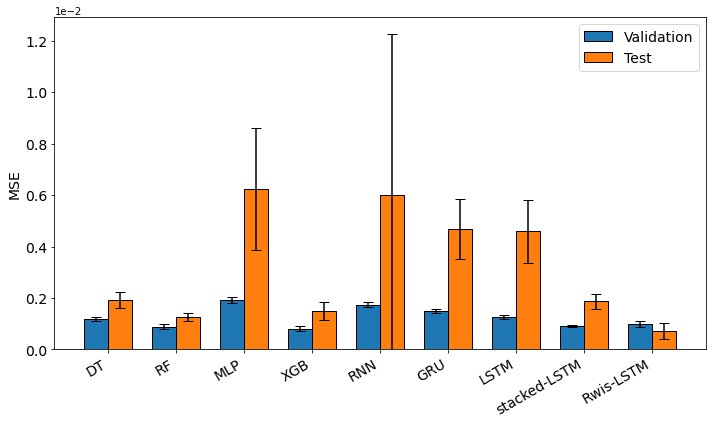

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取 Excel
df = pd.read_excel('results.xlsx', sheet_name='leave_out_29')

# 2. 提取数据
models     = df['model'].tolist()
val_means  = df['val_MSE_avg'].tolist()
test_means = df['test_MSE_avg'].tolist()
val_stds   = df['val_MSE_std'].tolist()
test_stds  = df['test_MSE_std'].tolist()

# 3. 绘图准备
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# 4. 绘制柱状图及误差棒
ax.bar(x - width/2, val_means,  width, yerr=val_stds,  label='Validation', capsize=5,   edgecolor='black',   # 黑色边框
    linewidth=1)
ax.bar(x + width/2, test_means, width, yerr=test_stds, label='Test',       capsize=5,   edgecolor='black',   # 黑色边框
    linewidth=1)

# 5. 美化与标注
ax.set_ylabel('MSE',fontsize=14)
# ax.set_title('Validation vs Test R² by Model (Leave-out 158)')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right',fontsize=14)
# plt.ylim(0,2.5e-3)
ax.legend(fontsize=14)

ax.tick_params(axis='y', labelsize=14)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('leave out 29.png', dpi=600)


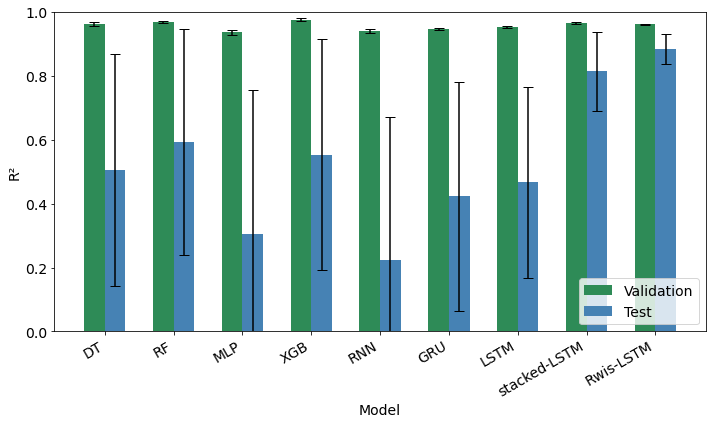

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取 Excel
df = pd.read_excel('results.xlsx', sheet_name='model_variance')

# 2. 提取数据
models     = df['model'].tolist()
val_means  = df['val_R2_avg'].tolist()
test_means = df['test_R2_avg'].tolist()
val_stds   = df['val_R2_std'].tolist()
test_stds  = df['test_R2_std'].tolist()

# 3. 绘图准备
x = np.arange(len(models))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 6))

# 4. 绘制柱状图及误差棒
ax.bar(x - width/2, val_means,  width, yerr=val_stds,  label='Validation', capsize=5,color='seagreen')
ax.bar(x + width/2, test_means, width, yerr=test_stds, label='Test',       capsize=5,color='steelblue')

# 5. 美化与标注
ax.set_ylabel('R²',fontsize=14)
ax.set_xlabel('Model',fontsize=14)
# ax.set_title('Validation vs Test R² by Model (Leave-out 27)')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right',fontsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.ylim(0,1)
# ax.legend()
ax.legend(loc='lower right',fontsize=14)
# ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig('model variance.png', dpi=600)


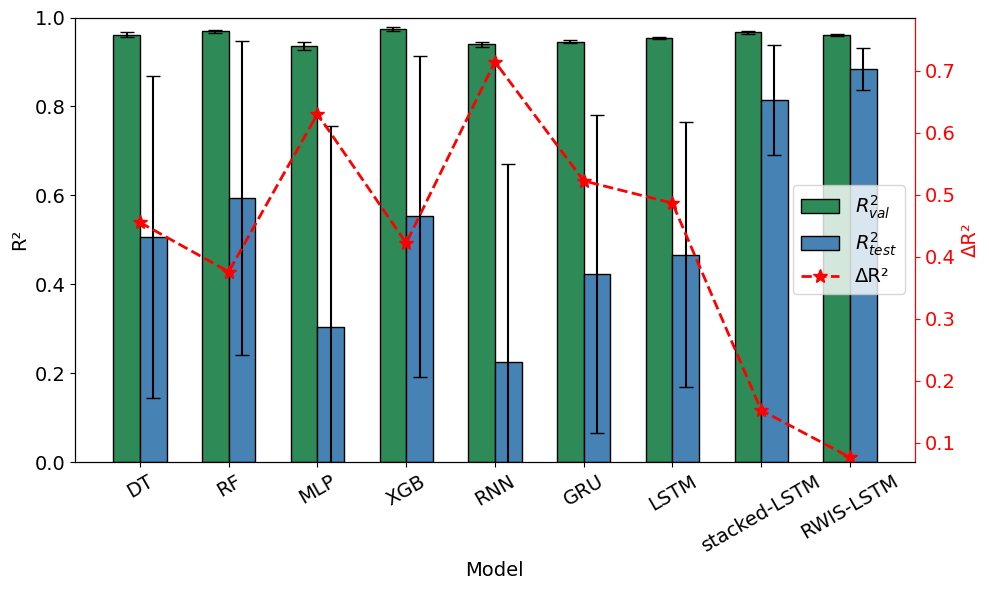

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取 Excel
df = pd.read_excel('results.xlsx', sheet_name='model_variance')

# 2. 提取数据
models     = df['model'].tolist()
val_means  = df['val_R2_avg'].tolist()
test_means = df['test_R2_avg'].tolist()
val_stds   = df['val_R2_std'].tolist()
test_stds  = df['test_R2_std'].tolist()
delta_r2   = df['delta_R2'].tolist()  # 或者 'delta_R2'

# 3. 绘图准备
x = np.arange(len(models))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 6))

# 4. 绘制双柱状图及误差棒（左 y 轴）
bars1 = ax.bar(x - width/2, val_means,  width, yerr=val_stds,
               label=r'$R^2_{val}$', capsize=5, color='seagreen',   edgecolor='black',   # 黑色边框
    linewidth=1  )
bars2 = ax.bar(x + width/2, test_means, width, yerr=test_stds,
               label=r'$R^2_{test}$',       capsize=5, color='steelblue',    edgecolor='black',   # 黑色边框
    linewidth=1  )

ax.set_ylabel('R²', fontsize=14)
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='center', fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# 5. 添加次要 y 轴并绘制 ΔR² 折线（红色）
ax2 = ax.twinx()
line, = ax2.plot(x, delta_r2, marker='*',markersize=10, linestyle='--', label='ΔR²',
                 linewidth=2, color='red')
ax2.set_ylabel('ΔR²', fontsize=14, color='red')
# 根据 delta_r2 值范围调整
ax2.set_ylim(min(delta_r2) * 0.9, max(delta_r2) * 1.1)

# 右侧 y 轴刻度和脊梁也设为红色
ax2.tick_params(axis='y', labelsize=14, colors='red')
ax2.spines['right'].set_color('red')

# 6. 图例合并
lines = [bars1, bars2, line]
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='center right', fontsize=14)
ax.set_xlabel('Model',fontsize=14)

plt.tight_layout()
plt.savefig('model_variance_with_delta.png', dpi=600)
plt.show()


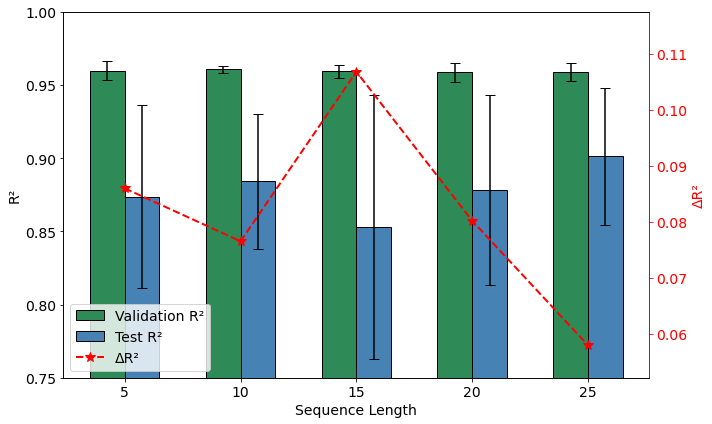

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取 Excel
df = pd.read_excel('results.xlsx', sheet_name='different_length')

# 2. 提取数据
models     = df['length'].tolist()
val_means  = df['val_R2_avg'].tolist()
test_means = df['test_R2_avg'].tolist()
val_stds   = df['val_R2_std'].tolist()
test_stds  = df['test_R2_std'].tolist()
delta_r2   = df['delta_R2'].tolist()  # 或者 'delta_R2'

# 3. 绘图准备
x = np.arange(len(models))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 6))

# 4. 绘制双柱状图及误差棒（左 y 轴）
bars1 = ax.bar(x - width/2, val_means,  width, yerr=val_stds,
               label='Validation R²', capsize=5, color='seagreen',   edgecolor='black',   # 黑色边框
    linewidth=1  )
bars2 = ax.bar(x + width/2, test_means, width, yerr=test_stds,
               label='Test R²', capsize=5, color='steelblue',    edgecolor='black',   # 黑色边框
    linewidth=1  )

ax.set_ylabel('R²', fontsize=14)
ax.set_ylim(0.75, 1)
ax.set_xticks(x)
ax.set_xticklabels(models,  ha='center', fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# 5. 添加次要 y 轴并绘制 ΔR² 折线（红色）
ax2 = ax.twinx()
line, = ax2.plot(x, delta_r2, marker='*',markersize=10, linestyle='--', label='ΔR²',
                 linewidth=2, color='red')
ax2.set_ylabel('ΔR²', fontsize=14, color='red')
# 根据 delta_r2 值范围调整
ax2.set_ylim(min(delta_r2) * 0.9, max(delta_r2) * 1.1)

# 右侧 y 轴刻度和脊梁也设为红色
ax2.tick_params(axis='y', labelsize=14, colors='red')
ax2.spines['right'].set_color('red')

# 6. 图例合并
lines = [bars1, bars2, line]
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='lower left', fontsize=14)
ax.set_xlabel('Sequence Length',fontsize=14)
plt.tight_layout()
plt.savefig('different_length.png', dpi=600)
plt.show()


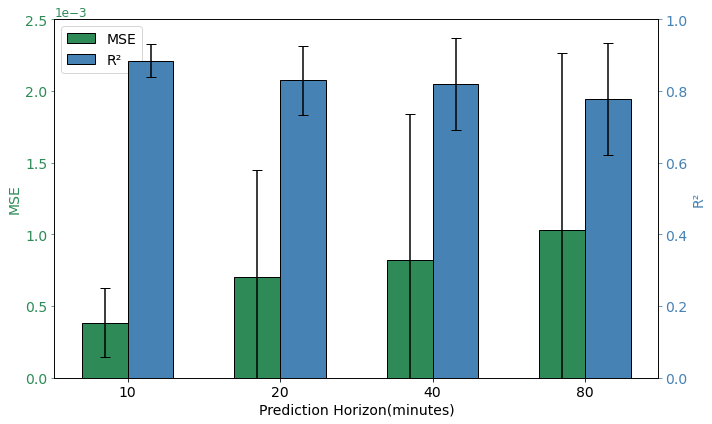

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取 Excel
df = pd.read_excel('results.xlsx', sheet_name='output_compare')

# 2. 提取数据
models     = df['output'].tolist()
MSE_means  = df['MSE-mean'].tolist()
R2_means = df['R2-mean'].tolist()
MSE_stds   = df['MSE-std'].tolist()
R2_stds  = df['R2-std'].tolist()


# 3. 绘图准备
x = np.arange(len(models))
width = 0.3

fig, ax1 = plt.subplots(figsize=(10, 6))

# left‑hand bars (Validation R²) on ax1
bars1 = ax1.bar(
    x - width/2, MSE_means, width,
    yerr=MSE_stds, capsize=5,
    label='MSE',color='seagreen',
    edgecolor='black', linewidth=1
)
ax1.set_ylabel('MSE', fontsize=14, color='seagreen')
ax1.tick_params(axis='y', labelsize=14, colors='seagreen')
# 强制左轴科学记数法，并固定为 ×10⁻³
ax1.ticklabel_format(style='sci', axis='y', scilimits=(-3, -3))
ax1.yaxis.get_offset_text().set_fontsize(12)  # 调整“×10⁻³”字体大小
ax1.set_ylim(0, 0.0025)

# create a second y‑axis sharing the same x
ax2 = ax1.twinx()

# right‑hand bars (Test R²) on ax2
bars2 = ax2.bar(
    x + width/2, R2_means, width,
    yerr=R2_stds, capsize=5,
    label='R²',color='steelblue',
    edgecolor='black', linewidth=1
)
ax2.set_ylabel('R²', fontsize=14, color='steelblue')
ax2.tick_params(axis='y', labelsize=14, colors='steelblue')
ax2.set_ylim(0, 1)

# common x‑axis tweaks
ax1.set_xticks(x)
ax1.set_xticklabels(models, ha='center', fontsize=14)
ax1.set_xlabel('Output Length', fontsize=14)

# combined legend
lines = [bars1, bars2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=14)

ax1.set_xlabel('Prediction Horizon(minutes)', fontsize=14)
plt.xticks(x, [10,20,40,80])

plt.tight_layout()
plt.savefig('different_output.png', dpi=600)
plt.show()


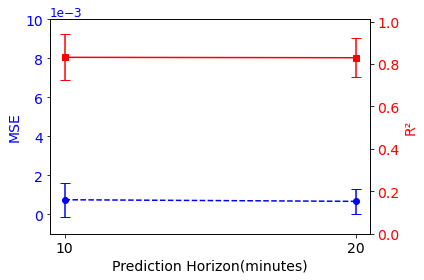

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Output 2 数据 (folds 1–2)
means2 = np.array([
    0.000747447,  0.831375296,
    0.000664917,  0.829376718
]).reshape(2, 2)
stds2 = np.array([
    0.000860648,  0.108295864,
    0.000643587,  0.091433744
]).reshape(2, 2)

x2 = np.arange(1, 3)
mse2, r22         = means2[:,0], means2[:,1]
mse2_std, r22_std = stds2[:,0], stds2[:,1]

fig, ax1 = plt.subplots(figsize=(6, 4))

# MSE (蓝色虚线)
ax1.errorbar(
    x2, mse2, yerr=mse2_std,
    marker='o', linestyle='--', color='blue', capsize=5
)
ax1.set_xlabel('Output', fontsize=14)
ax1.set_ylabel('MSE', fontsize=14, color='blue')
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14, labelcolor='blue')
ax1.set_xticks(x2)

# 强制左轴科学记数法，并固定为 ×10⁻³
ax1.ticklabel_format(style='sci', axis='y', scilimits=(-3, -3))
ax1.yaxis.get_offset_text().set_fontsize(12)  # 调整“×10⁻³”字体大小

# R² (红色实线)
ax2 = ax1.twinx()
ax2.errorbar(
    x2, r22, yerr=r22_std,
    marker='s', linestyle='-', color='red', capsize=5
)
ax2.set_ylabel('R²', fontsize=14, color='red')
ax2.tick_params(axis='y', labelsize=14, labelcolor='red')

# 设置轴范围
ax2.set_ylim(0, 1.01)
ax1.set_ylim(-0.001, 0.01)
ax1.set_xlabel('Prediction Horizon(minutes)', fontsize=14)
plt.xticks(x2, [f"{i*10}" for i in x2])

plt.tight_layout()
plt.savefig('output_2.png', dpi=600)


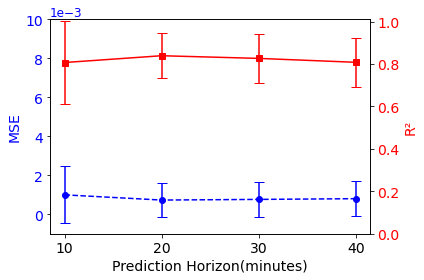

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker  # ← new

# Output 4 数据 (folds 1–4)
means4 = np.array([
    0.00099875,   0.806817272,
    0.000731008,  0.838853476,
    0.000764951,  0.826284023,
    0.000801275,  0.807900573
]).reshape(4, 2)
stds4 = np.array([
    0.001457646,  0.19599514,
    0.000851094,  0.105597363,
    0.000908187,  0.11534251,
    0.000891649,  0.115766238
]).reshape(4, 2)

x4 = np.arange(1, 5)
mse4, r24        = means4[:,0], means4[:,1]
mse4_std, r24_std = stds4[:,0], stds4[:,1]

fig, ax1 = plt.subplots(figsize=(6, 4))

# MSE (蓝色虚线) and force sci notation ×10⁻³
ax1.errorbar(x4, mse4, yerr=mse4_std,
             marker='o', linestyle='--', color='blue', capsize=5)
ax1.set_xlabel('output', fontsize=14)
ax1.set_ylabel('MSE', fontsize=14, color='blue')
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14, labelcolor='blue')
ax1.set_xticks(x4)

# ← here: always use 10⁻³ scale
ax1.ticklabel_format(style='sci', axis='y', scilimits=(-3, -3))
ax1.yaxis.get_offset_text().set_fontsize(12)  # make the “×10⁻³” a bit larger if you like

# R² (红色实线)
ax2 = ax1.twinx()
ax2.errorbar(x4, r24, yerr=r24_std,
             marker='s', linestyle='-', color='red', capsize=5)
ax2.set_ylabel('R²', fontsize=14, color='red')
ax2.tick_params(axis='y', labelsize=14, labelcolor='red')

# 设置轴范围
ax2.set_ylim(0, 1.01)
ax1.set_ylim(-0.001, 0.01)
ax1.set_xlabel('Prediction Horizon(minutes)', fontsize=14)
plt.xticks(x4, [f"{i*10}" for i in x4])
plt.tight_layout()
plt.savefig('output_4.png', dpi=600)


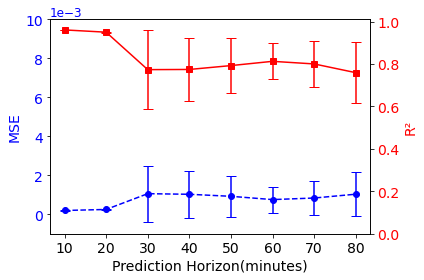

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker  # for scientific notation

# Output 8 数据 (folds 1–8)
means8 = np.array([
    0.000196144,  0.960456778,
    0.000249079,  0.949785016,
    0.001058257,  0.773334482,
    0.001027526,  0.774196189,
    0.000923361,  0.792404770,
    0.000754950,  0.812481347,
    0.000835862,  0.800169970,
    0.001031949,  0.759046982
]).reshape(8, 2)
stds8 = np.array([
    9.0007e-06,   0.001814539,
    1.27191e-05,  0.002564210,
    0.001427909,  0.187423359,
    0.001192199,  0.149902605,
    0.001045977,  0.130988719,
    0.000667236,  0.085353561,
    0.000853839,  0.108078781,
    0.001136465,  0.143548361
]).reshape(8, 2)

x8 = np.arange(1, 9)
mse8, r28       = means8[:,0], means8[:,1]
mse8_std, r28_std = stds8[:,0], stds8[:,1]

fig, ax1 = plt.subplots(figsize=(6, 4))

# MSE (蓝色虚线)
ax1.errorbar(
    x8, mse8, yerr=mse8_std,
    marker='o', linestyle='--', color='blue', capsize=5
)
ax1.set_xlabel('Prediction Horizon(minutes)', fontsize=14)
ax1.set_ylabel('MSE', fontsize=14, color='blue')
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14, labelcolor='blue')
ax1.set_xticks(x8)

# 左轴使用 ×10⁻³ 的科学记数法
ax1.ticklabel_format(style='sci', axis='y', scilimits=(-3, -3))
ax1.yaxis.get_offset_text().set_fontsize(12)

# R² (红色实线)
ax2 = ax1.twinx()
ax2.errorbar(
    x8, r28, yerr=r28_std,
    marker='s', linestyle='-', color='red', capsize=5
)
ax2.set_ylabel('R²', fontsize=14, color='red')
ax2.tick_params(axis='y', labelsize=14, labelcolor='red')



# 设置轴范围
ax2.set_ylim(0, 1.01)
ax1.set_ylim(-0.001, 0.01)
plt.xticks(x8, [f"{i*10}" for i in x8])

plt.tight_layout()
plt.savefig('output_8.png', dpi=600)


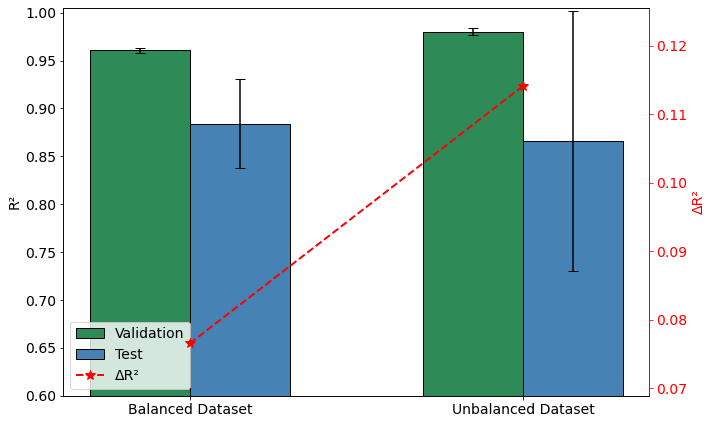

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取 Excel
df = pd.read_excel('results.xlsx', sheet_name='balance')

# 2. 提取数据
models     = df['model'].tolist()
val_means  = df['val_R2_avg'].tolist()
test_means = df['test_R2_avg'].tolist()
val_stds   = df['val_R2_std'].tolist()
test_stds  = df['test_R2_std'].tolist()
delta_r2   = df['delta_R2'].tolist()  # 或者 'delta_R2'

# 3. 绘图准备
x = np.arange(len(models))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 6))

# 4. 绘制双柱状图及误差棒（左 y 轴）
bars1 = ax.bar(x - width/2, val_means,  width, yerr=val_stds,
               label='Validation', capsize=5, color='seagreen',   edgecolor='black',   # 黑色边框
    linewidth=1  )
bars2 = ax.bar(x + width/2, test_means, width, yerr=test_stds,
               label='Test', capsize=5, color='steelblue',    edgecolor='black',   # 黑色边框
    linewidth=1  )

ax.set_ylabel('R²', fontsize=14)
ax.set_ylim(0.6, 1.005)
ax.set_xticks(x)
ax.set_xticklabels(models,  ha='center', fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# 5. 添加次要 y 轴并绘制 ΔR² 折线（红色）
ax2 = ax.twinx()
line, = ax2.plot(x, delta_r2, marker='*',markersize=10, linestyle='--', label='ΔR²',
                 linewidth=2, color='red')
ax2.set_ylabel('ΔR²', fontsize=14, color='red')
# 根据 delta_r2 值范围调整
ax2.set_ylim(min(delta_r2) * 0.9, max(delta_r2) * 1.1)

# 右侧 y 轴刻度和脊梁也设为红色
ax2.tick_params(axis='y', labelsize=14, colors='red')
ax2.spines['right'].set_color('red')

# 6. 图例合并
lines = [bars1, bars2, line]
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='lower left', fontsize=14)
# ax.set_xlabel('Sequence Length',fontsize=14)
plt.tight_layout()
plt.savefig('balanced.png', dpi=600)
plt.show()


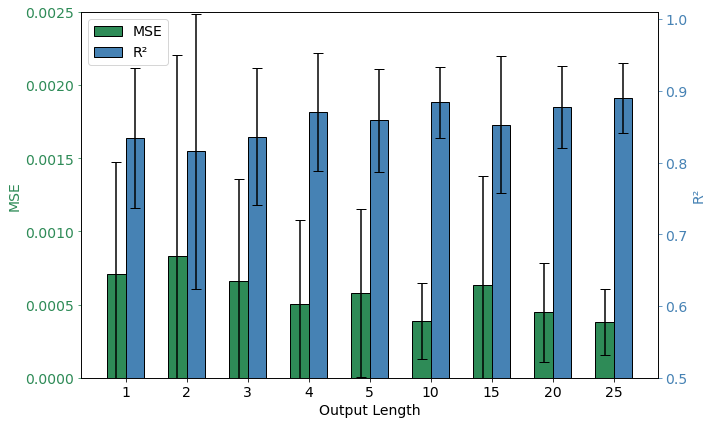

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取 Excel
df = pd.read_excel('results.xlsx', sheet_name='different_length')

# 2. 提取数据
models     = df['length'].tolist()
MSE_means  = df['MSE-mean'].tolist()
R2_means = df['R2-mean'].tolist()
MSE_stds   = df['MSE-std'].tolist()
R2_stds  = df['R2-std'].tolist()


# 3. 绘图准备
x = np.arange(len(models))
width = 0.3

fig, ax1 = plt.subplots(figsize=(10, 6))

# left‑hand bars (Validation R²) on ax1
bars1 = ax1.bar(
    x - width/2, MSE_means, width,
    yerr=MSE_stds, capsize=5,
    label='MSE',color='seagreen',
    edgecolor='black', linewidth=1
)
ax1.set_ylabel('MSE', fontsize=14, color='seagreen')
ax1.tick_params(axis='y', labelsize=14, colors='seagreen')
ax1.set_ylim(0, 0.0025)

# create a second y‑axis sharing the same x
ax2 = ax1.twinx()

# right‑hand bars (Test R²) on ax2
bars2 = ax2.bar(
    x + width/2, R2_means, width,
    yerr=R2_stds, capsize=5,
    label='R²',color='steelblue',
    edgecolor='black', linewidth=1
)
ax2.set_ylabel('R²', fontsize=14, color='steelblue')
ax2.tick_params(axis='y', labelsize=14, colors='steelblue')
ax2.set_ylim(0.5, 1.01)

# common x‑axis tweaks
ax1.set_xticks(x)
ax1.set_xticklabels(models, ha='center', fontsize=14)
ax1.set_xlabel('Output Length', fontsize=14)

# combined legend
lines = [bars1, bars2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=14)

plt.tight_layout()
plt.savefig('different_length.png', dpi=600)
plt.show()


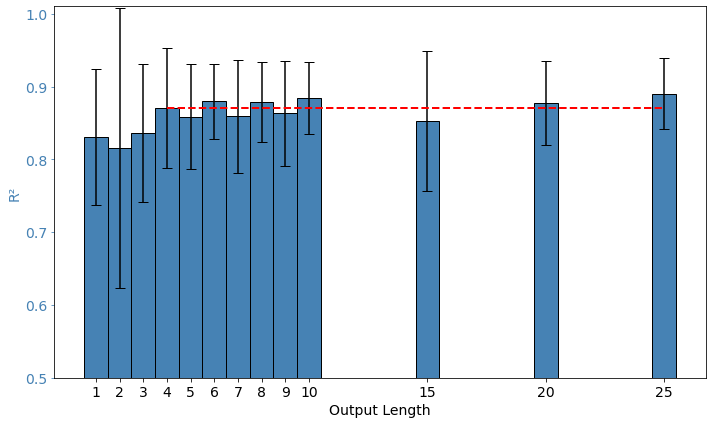

In [147]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取 Excel
df = pd.read_excel('results.xlsx', sheet_name='different_length')

# 2. 提取数据
models    = df['length'].tolist()
R2_means  = df['R2-mean'].tolist()
R2_stds   = df['R2-std'].tolist()

# 3. 用真实的 length 做 x 坐标
x = np.array(models, dtype=float)
width = 1.0  # 柱宽

fig, ax = plt.subplots(figsize=(10, 6))

# 绘制 R² 柱状图
bars = ax.bar(
    x, R2_means, width,
    yerr=R2_stds, capsize=5,
    label='R²',
    color='steelblue', edgecolor='black', linewidth=1
)

# 添加水平虚线：y = 0.85，在 x = 4 到 x = 25 之间
ax.plot([4, 25], [0.87, 0.87],
        linestyle='--', linewidth=2,
        color='red', label='y = 0.9')

# 坐标轴、刻度及图例
ax.set_ylabel('R²', fontsize=14, color='steelblue')
ax.tick_params(axis='y', labelsize=14, colors='steelblue')
ax.set_ylim(0.5, 1.01)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=14)
ax.set_xlabel('Output Length', fontsize=14)

# ax.legend(fontsize=14)

plt.tight_layout()
plt.savefig('different_length_R2_with_line.png', dpi=600)
plt.show()


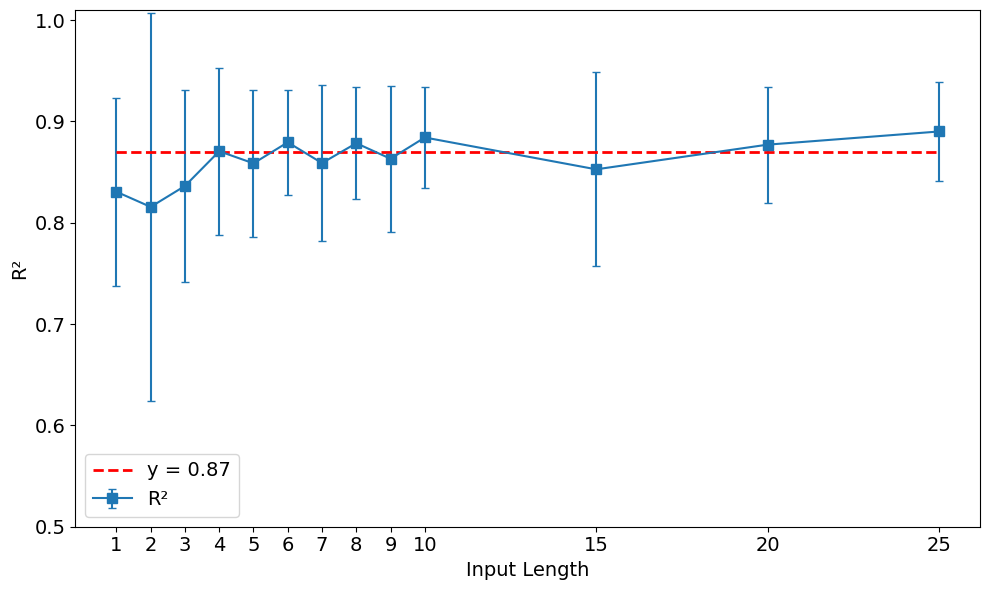

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取 Excel
df = pd.read_excel('results.xlsx', sheet_name='different_length')

# 2. 提取数据
models    = df['length'].tolist()
R2_means  = df['R2-mean'].tolist()
R2_stds   = df['R2-std'].tolist()

# 3. 用真实的 length 做 x 坐标
x = np.array(models, dtype=float)

fig, ax = plt.subplots(figsize=(10, 6))

# === 改动部分：用折线图＋误差条替换柱状图 ===
ax.errorbar(
    x, R2_means,
    yerr=R2_stds,
        # 实心圆标记 + 实线
    capsize=3,        # 误差条帽宽
    label='R²',marker='s',markersize=7
)

# 如果你想用“误差带”而不是误差条，也可以这样做：
# ax.plot(x, R2_means, marker='o', label='R²')
# ax.fill_between(x, 
#                 np.array(R2_means) - np.array(R2_stds),
#                 np.array(R2_means) + np.array(R2_stds),
#                 alpha=0.2)

# 添加水平虚线：y = 0.87，在 x = 4 到 x = 25 之间
ax.plot([1, 25], [0.87, 0.87],
        linestyle='--', linewidth=2,
        color='red', label='y = 0.87')

# 坐标轴、刻度及图例
ax.set_ylabel('R²', fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.set_ylim(0.5, 1.01)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=14)
ax.set_xlabel('Input Length', fontsize=14)

ax.legend(fontsize=14)

plt.tight_layout()
plt.savefig('different_length_R2_line_with_error.png', dpi=600)
plt.show()


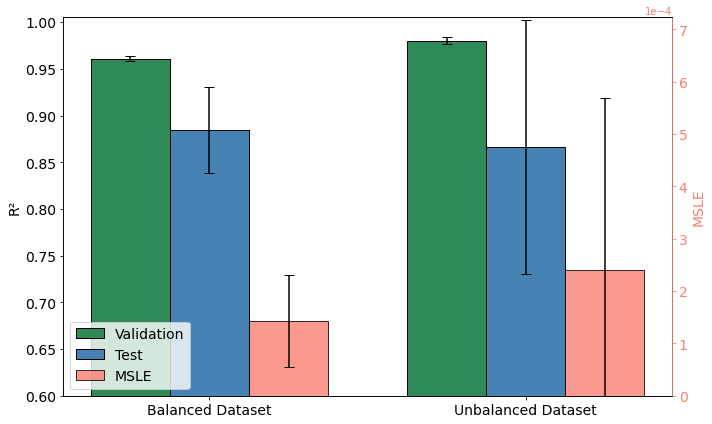

In [146]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

# 1. 读取 Excel
df = pd.read_excel('results.xlsx', sheet_name='balance')

# 2. 提取数据
models      = df['model'].tolist()
val_means   = df['val_R2_avg'].tolist()
test_means  = df['test_R2_avg'].tolist()
val_stds    = df['val_R2_std'].tolist()
test_stds   = df['test_R2_std'].tolist()

msle_means  = df['MSLE-mean'].tolist()
msle_stds   = df['MSLE-std'].tolist()

# 3. 绘图准备
x     = np.arange(len(models))
width = 0.25  # 三组柱子，要比之前更窄一些

fig, ax = plt.subplots(figsize=(10, 6))

# 4. 左侧 R² 柱状
bars_val = ax.bar(
    x - width, val_means, width, yerr=val_stds, capsize=5,
    label='Validation', color='seagreen', edgecolor='black', linewidth=1
)
bars_test = ax.bar(
    x, test_means, width, yerr=test_stds, capsize=5,
    label='Test', color='steelblue', edgecolor='black', linewidth=1
)

ax.set_ylabel('R²', fontsize=14)
ax.set_ylim(0.6, 1.005)
ax.set_xticks(x)
ax.set_xticklabels(models, ha='center', fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# 5. 右侧 MSLE 柱状
ax2 = ax.twinx()
bars_msle = ax2.bar(
    x + width, msle_means, width, yerr=msle_stds, capsize=5,
    label='MSLE', color='salmon', edgecolor='black', linewidth=1, alpha=0.8
)
ax2.set_ylabel('MSLE', fontsize=14, color='salmon')

# ========== 新增：科学记数法 ==========
# 方法一：直接用 ticklabel_format
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
# 或者方法二：用 ScalarFormatter
# fmt = ScalarFormatter(useMathText=True)
# fmt.set_powerlimits((0,0))
# ax2.yaxis.set_major_formatter(fmt)
# ====================================

# 让 MSLE 轴从 0 开始，上限留 10% 余量
ax2.set_ylim(0, max(msle_means) * 3)

ax2.tick_params(axis='y', labelsize=14, colors='salmon')
ax2.spines['right'].set_color('salmon')

# 6. 合并图例
all_bars = [bars_val, bars_test, bars_msle]
labels   = [b.get_label() for b in all_bars]
ax.legend(all_bars, labels, loc='lower left', fontsize=14)

plt.tight_layout()
plt.savefig('balanced_with_MSLE_bars_sci.png', dpi=600)
plt.show()
